In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,confusion_matrix
from sklearn.preprocessing import StandardScaler
import sys
sys.path.append("eval.py") 
from eval import notation


In [3]:
data_1 = pd.read_csv("./data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
data_2 = pd.read_csv("./data/2023-02-12.csv")

data_1.columns = data_1.columns.str.replace(" ", "").str.lower()
data_2.columns = data_2.columns.str.replace(" ", "").str.lower()

common_columns = list(set(data_1.columns) & set(data_2.columns))

data_1 = data_1[common_columns]
data_2 = data_2[common_columns]

concatenated_data = pd.concat([data_1, data_2], ignore_index=True)
concatenated_data["label_ml"] = (concatenated_data["label"] != "BENIGN").astype(int)
concatenated_data["label_dl"]  = concatenated_data["label"]
concatenated_data = concatenated_data.drop(columns=["label"])

concatenated_data.replace([np.inf, -np.inf], np.nan, inplace=True)
concatenated_data.dropna(inplace=True)
concatenated_data = concatenated_data.sort_values(by="label_dl")



In [4]:
concatenated_data

,flowpackets/s,synflagcount,bwdurgflags,bwdpacketlengthstd,bwdiatmin,idlemean,bwdiatmax,down/upratio,bwdheaderlength,averagepacketsize,...,fwdpshflags,rstflagcount,flowiatmax,activemin,activemean,fwdpacketlengthmean,subflowfwdbytes,fwdiatmin,label_ml,label_dl
0,666666.666700,0,0,0.000000,0.0,0.000000e+00,0.0,0.0,0,9.000000,...,0,0,3.0,0.0,0.0,6.000000,12,3.0,0,BENIGN
186567,0.739692,0,0,0.000000,1.0,8.097891e+06,8097891.0,5.0,100,7.000000,...,0,0,8097891.0,13596.0,13596.0,6.000000,6,0.0,0,BENIGN
186568,1.370023,1,0,2.449490,983.0,5.099590e+06,5099590.0,6.0,132,397.142857,...,1,0,5099590.0,9814.0,9814.0,1375.000000,1375,0.0,0,BENIGN
186569,0.868456,1,0,2.449490,1.0,8.031809e+06,8031809.0,6.0,132,397.142857,...,1,0,8031809.0,28474.0,28474.0,1375.000000,1375,0.0,0,BENIGN
186570,1.645324,0,0,0.000000,1.0,0.000000e+00,4221864.0,6.0,120,6.857143,...,0,0,4221864.0,0.0,0.0,6.000000,6,0.0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232041,0.223077,7,0,0.000000,1011067.0,5.587225e+14,16128058.0,6.0,144,0.000000,...,0,0,16128058.0,7059238.0,7059238.0,0.000000,0,0.0,1,redispot
243393,55.079728,0,0,0.000000,0.0,1.676177e+15,0.0,1.0,32,0.000000,...,0,0,36311.0,0.0,0.0,0.000000,0,0.0,1,redispot
243392,98.527506,2,0,647.122518,19.0,1.676177e+15,46457.0,0.0,264,185.950000,...,0,0,36663.0,0.0,0.0,5.333333,3,0.0,1,redispot
269742,3.351911,2,0,26.693528,297.0,8.381004e+14,7183666.0,0.0,328,18.448276,...,0,0,7053064.0,682687.0,682687.0,17.578947,11,51728.0,1,redispot


In [5]:
X_ml = concatenated_data.drop(['label_dl', 'label_ml'], axis=1)
y_ml = concatenated_data['label_ml']

scaler = StandardScaler()
X_ml = scaler.fit_transform(X_ml)

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)


In [6]:
# entrainement modele

# 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 8, 'criterion': 'entropy'
model_ml = DecisionTreeClassifier(max_depth=8, min_samples_split=9 , min_samples_leaf=8, criterion='entropy')
model_ml.fit(X_train_ml, y_train_ml)


concatenated_data["predict_ml"] = model_ml.predict(X_ml)

In [7]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Supposons que concatenated_data est votre DataFrame original

# Filtrer les données pour exclure les échantillons avec predict_ml égal à 0
data_dl = concatenated_data[concatenated_data["label_ml"] != 0]

# Séparer les caractéristiques et la cible
X_dl = data_dl.drop(['label_dl', 'label_ml', 'predict_ml'], axis=1)
y_dl = data_dl['label_dl']

# Encoder les étiquettes de la cible
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_dl)
y_categorical = to_categorical(y_encoded)

# Normaliser les données
scaler = StandardScaler()
X_dl = scaler.fit_transform(X_dl)

# Diviser les données en ensembles d'entraînement et de test
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_categorical, test_size=0.2, random_state=42)

# Construction du modèle ANN
model_dl = Sequential()
model_dl.add(Dense(64, input_dim=X_train_dl.shape[1], activation='relu'))
model_dl.add(Dense(32, activation='relu'))
model_dl.add(Dense(16, activation='relu'))
model_dl.add(Dense(y_categorical.shape[1], activation='softmax'))  # Pour une classification multi-classes

# Compilation du modèle
model_dl.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
history = model_dl.fit(X_train_dl, y_train_dl, epochs=20, batch_size=32, validation_split=0.2)

# Évaluation du modèle
loss, accuracy = model_dl.evaluate(X_test_dl, y_test_dl)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

c:\Users\allan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9455 - loss: 0.1575 - val_accuracy: 0.9951 - val_loss: 0.0164
Epoch 2/20
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9953 - loss: 0.0156 - val_accuracy: 0.9957 - val_loss: 0.0164
Epoch 3/20
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9957 - loss: 0.0144 - val_accuracy: 0.9960 - val_loss: 0.0144
Epoch 4/20
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9961 - loss: 0.0131 - val_accuracy: 0.9961 - val_loss: 0.0140
Epoch 5/20
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9966 - loss: 0.0116 - val_accuracy: 0.9958 - val_loss: 0.0135
Epoch 6/20
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9963 - loss: 0.0123 - val_accuracy: 0.9961 - val_loss: 0.0135
Epoch 7/20
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9964 - loss: 0.0118 - val_accuracy: 0.9959 - val_loss: 0.0132
Epoch 8/20
4084/4084 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9964 - loss: 0.0111 - 

In [ ]:
data_dl = concatenated_data[concatenated_data["predict_ml"] == 1]
data_dl_2 = concatenated_data[concatenated_data["predict_ml"] == 0]

col_lab = data_dl[['label_dl', 'label_ml', 'predict_ml']]
data_final = data_dl.drop(['label_dl', 'label_ml', 'predict_ml'], axis=1)
y_pred_dl = model_dl.predict(data_final)

# Convertir les prédictions en étiquettes lisibles
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_dl, axis=1))

# Ajouter les prédictions au DataFrame data_dl
data_final['predict_dl'] = y_pred_labels

data_dl_2['predict_dl'] = "BENIGN"
data_final[['label_dl', 'label_ml', 'predict_ml']] = col_lab

data_final_2 = pd.concat([data_final, data_dl_2])
data_final_2.sort_values(by="label_dl", inplace=True)

6378/6378 ━━━━━━━━━━━━━━━━━━━━ 4s 687us/step


In [39]:
y_test = data_final_2['label_dl']
y_pred = data_final_2['predict_dl']

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')  # ou 'macro'
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Confusion Matrix: \n {conf_matrix}")

c:\Users\allan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.7253065767419058
Precision: 0.8658561849517735
Recall: 0.7253065767419058
F1 Score: 0.7168033334553282
Confusion Matrix: 
 [[97678     0     0     0     0     8     0     0     0     0]
 [  130 49013     0     0  9209 69673     0     0     0     0]
 [    0     0     0     0     0   180     0     0     0     0]
 [    0     0     0     0     0   175     0     0     0     0]
 [    0     0     0     0     0  2078     0     0     0     0]
 [    0     0     0     0     0 72266     0     0     0     0]
 [    0     0     0     0     0    62     0     0     0     0]
 [    1     0     0     0     0  1325     0     0     0     0]
 [    0     0     0     0     0    49     0     0     0     0]
 [    0     0     0     0     0    35     0     0     0     0]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, confusion_matrix, recall_score
import numpy as np

# Définir le modèle
model = DecisionTreeClassifier(random_state=42)

# Définir l'espace des hyperparamètres
param_dist = {
    'max_depth': np.arange(1, 21),
    'min_samples_split': np.arange(2, 21),
    'min_samples_leaf': np.arange(1, 21),
    'criterion': ['gini', 'entropy']
}

# Définir une fonction de scoring personnalisée pour maximiser tp et minimiser fp
def custom_scorer(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (tp - fp) / (tp + fp + 1e-6)  # Ajout d'un petit terme pour éviter la division par zéro

# Créer un objet RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=100,  # Nombre d'itérations
    scoring=make_scorer(custom_scorer),
    cv=5,  # Nombre de folds pour la validation croisée
    random_state=42,
    n_jobs=-1  # Utiliser tous les processeurs disponibles
)

# Effectuer la recherche
random_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres
print("Meilleurs paramètres (Random Search):", random_search.best_params_)
print("Meilleur score (Random Search):", random_search.best_score_)


Meilleurs paramètres (Random Search): {'min_samples_split': np.int64(15), 'min_samples_leaf': np.int64(6), 'max_depth': np.int64(9), 'criterion': 'entropy'}
Meilleur score (Random Search): 0.9997060562874536


In [ ]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, confusion_matrix

# Définir la fonction objective pour Optuna
def objective(trial):
    # Définir les hyperparamètres à optimiser
    max_depth = trial.suggest_int('max_depth', 1, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    # Créer le modèle avec les hyperparamètres suggérés
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42
    )

    # Définir une fonction de scoring personnalisée
    def custom_scorer(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return (tp - fp) / (tp + fp + 1e-6)  # Ajout d'un petit terme pour éviter la division par zéro

    # Évaluer le modèle avec validation croisée
    score = cross_val_score(model, X_train, y_train, cv=5, scoring=make_scorer(custom_scorer))

    # Retourner la moyenne des scores
    return score.mean()

# Créer un objet study Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Afficher les meilleurs paramètres
print("Meilleurs paramètres (Optuna):", study.best_params)
print("Meilleur score (Optuna):", study.best_value)


c:\Users\allan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-02-25 11:22:13,545] A new study created in memory with name: no-name-ce235f4c-4c1b-455b-bade-05ee2134d3ff
[I 2025-02-25 11:22:22,501] Trial 0 finished with value: 0.8780528906590106 and parameters: {'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 8, 'criterion': 'gini'}. Best is trial 0 with value: 0.8780528906590106.
[I 2025-02-25 11:22:42,112] Trial 1 finished with value: 0.9996360679797427 and parameters: {'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 12, 'criterion': 'entropy'}. Best is trial 1 with value: 0.9996360679797427.
[I 2025-02-25 11:22:51,481] Trial 2 finished with value: 0.9487463685653076 and parameters: {'max_depth': 4, 'min_samples_split': 20, 'min_samples_leaf

Meilleurs paramètres (Optuna): {'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 8, 'criterion': 'entropy'}
Meilleur score (Optuna): 0.9997480236141143


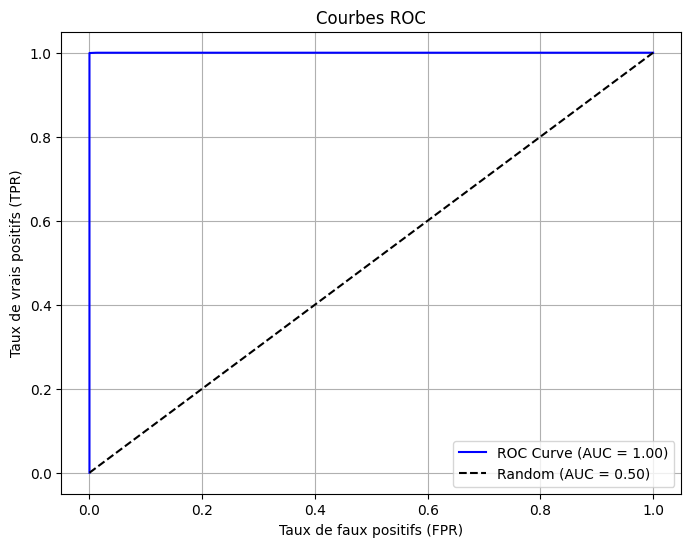

(0.9994534342547658,
 0.999454005221736,
 0.9994534342547658,
 0.9994535245444796,
 array([[19604,     4],
        [   29, 40740]]),
 'AUC-ROC: 1.0000000000')

In [ ]:
notation(X_test, y_test, y_pred, model)